In [1]:
from astropy.visualization import ImageNormalize,SqrtStretch,LinearStretch,LogStretch,MinMaxInterval,ZScaleInterval
from importlib import reload,import_module
from scipy.stats import truncnorm,norm
import matplotlib.pyplot as pl
import pandas as pd
import numpy as np
import glob
import sys
import os
sys.path.append('/mnt/users/hollowayp/paltas/paltas/')
sys.path.append('/mnt/users/hollowayp/paltas/')
from paltas.Configs.config_handler import ConfigHandler
from plot_image_collage import plot_collage
from load_h5_file import load_h5_file

try: reload(sys.modules['paltas.Configs.config_handler'])
except Exception as ex: print(ex)
try: reload(sys.modules['generate'])
except Exception as ex: print(ex)

from generate_predictions import gen_network_predictions_single,gen_network_predictions_general
from load_model import load_model
from generate import *

2025-07-15 13:33:35.723005: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-15 13:33:41.392605: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-15 13:33:42.747057: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-15 13:33:42.981011: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-15 13:33:46.517764: I tensorflow/core/platform/cpu_feature_guar

'generate'


['/mnt/zfsusers/hollowayp/paltas/SW_outreach/image_3p0.npy', '/mnt/zfsusers/hollowayp/paltas/SW_outreach/image_2p0.npy', '/mnt/zfsusers/hollowayp/paltas/SW_outreach/image_2p5.npy', '/mnt/zfsusers/hollowayp/paltas/SW_outreach/image_1p5.npy']


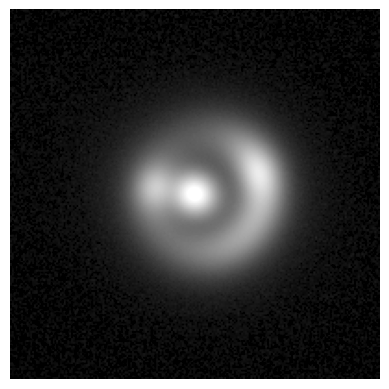

In [42]:
##Just generating some lensing images
# import cv2
outreach_folder = '/mnt/zfsusers/hollowayp/paltas/SW_outreach/'
print(glob.glob(outreach_folder+'*.npy'))
for im in glob.glob(outreach_folder+'*.npy'):
    image_i = np.load(im)
    pl.imshow(image_i,cmap='gray',norm=ImageNormalize(vmin=0,vmax=np.percentile(image_i,99.9),stretch=SqrtStretch()))
    # pl.title(im.split('/')[-1])
    pl.axis('off')
    pl.savefig(im.replace('.npy','.png'),bbox_inches='tight',dpi=300)

In [20]:
sys.path.append('/mnt/users/hollowayp/Documents/project_2/')
from retrieve_HSC_databases import HS_X_db

HS_X_lenses = glob.glob('/mnt/users/hollowayp/Documents/project_2/HOLISMOKES_X_HSC_Cutouts/cropped_cutouts/*.npy')
HS_X_lenses[0]

'/mnt/users/hollowayp/Documents/project_2/HOLISMOKES_X_HSC_Cutouts/cropped_cutouts/HSCJ125254+004356.npy'

In [21]:
def generate_config_module(blank_config, 
                           main_deflector_parameters = {},
                           lens_light_parameters = {},
                           source_parameters = {},
                           PSF_parameters = {'fwhm':0.8}, #Roughly LSST
                           detector_parameters = {'ccd_gain':0.7,'read_noise':10}, #Roughly (but not exactly) DP0-like.
                           lens_subtraction = False,
                           add_RSP_background = False,
                           RSP_cutout_folder= '/mnt/zfsusers/hollowayp/paltas/RSP_Coadd_Files_100000/',
                           RSP_ZP = 27, #Zeropoint for the coadds
                           output_ab_zeropoint = 27.85,
                           ):
    print(f'RSP background will {(not add_RSP_background)*"NOT "}be added to the images.')
    config_dir, config_file = os.path.split(os.path.abspath(blank_config))
    sys.path.insert(0, config_dir)
    config_name, _ = os.path.splitext(config_file)
    config_module = import_module(config_name)
    for key in main_deflector_parameters:
        config_module.config_dict['main_deflector']['parameters'][key] = main_deflector_parameters[key]
    for key in lens_light_parameters:
        config_module.config_dict['lens_light']['parameters'][key] = lens_light_parameters[key]
    for key in source_parameters:
        config_module.config_dict['source']['parameters'][key] = source_parameters[key]
    for key in PSF_parameters:
        config_module.config_dict['psf']['parameters'][key] = PSF_parameters[key]
    for key in detector_parameters:
        config_module.config_dict['detector']['parameters'][key] = detector_parameters[key]
    for dict_i in [config_module.config_dict['main_deflector'],
                   config_module.config_dict['lens_light'],
                   config_module.config_dict['source']]:
        dict_i['parameters']['output_ab_zeropoint'] = output_ab_zeropoint
    config_module.config_dict['detector']['parameters']['magnitude_zero_point'] = output_ab_zeropoint
    config_module.config_dict['lens_subtraction'] = lens_subtraction
    config_module.add_RSP_background = add_RSP_background
    config_module.RSP_cutout_folder = RSP_cutout_folder
    config_module.RSP_ZP = RSP_ZP
    config_module.output_ab_zeropoint = output_ab_zeropoint
    config_module.blank_config = blank_config
    # print(config_module.config_dict)
    assert 'TBD' not in [config_module.config_dict['detector']['parameters']['exposure_time'],
                            config_module.config_dict['detector']['parameters']['sky_brightness'],
                            config_module.config_dict['detector']['parameters']['num_exposures']]
    return config_module


In [4]:
class HiddenPrints:
    def __enter__(self):
        self._original_stdout = sys.stdout
        sys.stdout = open(os.devnull, 'w')

    def __exit__(self, exc_type, exc_val, exc_tb):
        sys.stdout.close()
        sys.stdout = self._original_stdout

In [22]:
def return_config_params(theta_E,
                         center_L,center_S,
                         e_L,
                         R_eff_L,R_eff_S,
                         mag_L,mag_S,
                         gamma_L,
                         gamma_vec = [0.0,0.0],
                         e_S = [0.0,0.0],
                         n_S = 1.0,n_L= 4.0,
                         zL = np.nan,zS = np.nan):
    main_deflector_parameters = {
        'M200': 1e13,
        'z_lens':zL,
        'gamma':gamma_L,
        'theta_E':theta_E,
        'e1':e_L[0],
        'e2':e_L[1],
        'center_x':center_L[0],
        'center_y':center_L[1],
        'gamma1':gamma_vec[0],
        'gamma2':gamma_vec[1],
        'ra_0':0.0, 'dec_0':0.0
        }
    lens_light_parameters = {
        'z_source':zL,
        'mag_app':mag_L,
        'R_sersic':R_eff_S,
        'n_sersic':n_S,
        'e1':e_S[0],
        'e2':e_S[1],
        'center_x':center_L[0],
        'center_y':center_L[1],
        }
    source_parameters = {
        'z_source':zS,
        'mag_app': mag_S,
        'R_sersic':R_eff_S,
        'n_sersic':n_S,
        'e1':e_S[0],
        'e2':e_S[1],
        'center_x':center_S[0],
        'center_y':center_S[1],
        }
    return main_deflector_parameters,lens_light_parameters,source_parameters

In [25]:
def plot_central_circle(N_pix_image,radius,color='white',linewidth=2,linestyle='-'): #radius is in pixels
    if N_pix_image%2==0: x_centre = (N_pix_image-1)/2
    else: x_centre = N_pix_image//2
    circle = pl.Circle((x_centre,x_centre),radius,color=color, fill=False,linewidth=linewidth,linestyle=linestyle)
    return circle

def plot_central_annulus(N_pix_image,midpoint_radius,width=None,low_err=None,up_err=None,color='white',hatch=None,
                         linewidth=3,linestyle='-'): #radius is in pixels
    if N_pix_image%2==0: x_centre = (N_pix_image-1)/2
    else: x_centre = N_pix_image//2
    if width is None:
        assert low_err is not None and up_err is not None
        low_radius = midpoint_radius-low_err
        up_radius = midpoint_radius+up_err
        annulus = Annulus((x_centre,x_centre), r=up_radius, width = up_err+low_err,color=color,fill=False,
                        hatch=hatch,linewidth=linewidth,linestyle=linestyle)
    #Multiply width by two as we want to plot mean + - std, i.e. total width is 2x std.
    else: annulus = Annulus((x_centre,x_centre), r=midpoint_radius+width, width=2*width,color=color,fill=False,
                        hatch=hatch,linewidth=linewidth,linestyle=linestyle)
    return annulus

def add_annulus_and_label(filename,pixel_scale,image,ax,radius_mu,radius_std,linewidth=3,linestyle='-'): #radius in arcsec
    # ra_i = fst.loc[int(filenames[i].split('/')[-1].replace('.npy',''))]['RA']
    # dec_i = fst.loc[int(filenames[i].split('/')[-1].replace('.npy',''))]['Dec']
    # c = SkyCoord(ra=ra_i*u.degree, dec=dec_i*u.degree)
    # ra_str_i = c.ra.to_string(unit=u.hourangle, sep='',pad=True, precision=0) # format hms
    # dec_str_i = c.dec.to_string(unit=u.degree, sep='',pad=True, alwayssign= True,precision=0) # format dms
    ax.set_title(filename.split('/')[-1],color='white', fontsize=18, y=0.85)
    circle = plot_central_annulus(image.shape[0],
        midpoint_radius = radius_mu/pixel_scale,
        width = radius_std/pixel_scale,
        color='red',
        linewidth=linewidth,
        linestyle=linestyle)
    ax.add_patch(circle)

In [26]:
import sys
sys.path.append('/mnt/users/hollowayp/Documents/project_2')
from importlib import reload
try: reload(sys.modules['HSC_Model_Prediction'])
except KeyError: pass
from HSC_Model_Prediction import retrieve_SuGOHI_data,retrieve_HOLISMOKES_X_data,predict_model_parameters,predict_SuGOHI_model_parameters,predict_HOLISMOKES_X_model_parameters


In [30]:
class generate_posterior_image_class:
    def __init__(self,folder_number,image_files_to_predict = [],N_post = 100,
                 weights_file = np.nan,image_folder = None,use_best_epoch=False): #image_folder is the folder where the image_files_to_predict are stored.
        self.N_post = N_post #Number of posterior samples
        self.folder_number = folder_number
        self.model_folder_affix='_no_subtr_LS_light_mu3'
        self.train_folder_affix='_no_subtr_LS_light_mu3'
        self.test_folder_affix='_no_subtr_LS_light'
        self.analysis_folder = 'paltas.Analysis.AnalysisConfigs'
        self.training_directory = f'/mnt/extraspace/hollowayp/paltas_data/Example_LP_{folder_number}{self.train_folder_affix}/' #For Glamdring (in extraspace)
        self.training_config_directory = f'{self.analysis_folder}.train_config_LSST_Lenspop{self.train_folder_affix}'#_no_subtr' #Keep Updated!
        self.test_directory = f'/mnt/extraspace/hollowayp/paltas_data/Example_LP_{folder_number}{self.test_folder_affix}/'
        self.model_directory = f'/mnt/extraspace/hollowayp/paltas_data/Example_LP_{folder_number}{self.model_folder_affix}/'
        self.image_files_to_predict = image_files_to_predict
        self.weights_file = weights_file
        self.image_folder = image_folder
        self.seed = 0
        db_WandB = pd.read_csv('WandB Loss Evolution.csv')
        min_val_loss_step = np.where(db_WandB[f'Example_LP_{folder_number}{self.model_folder_affix} - Val Loss']==db_WandB[f'Example_LP_{folder_number}{self.model_folder_affix} - Val Loss'].min())[0][0]
        min_val_loss_epoch = min_val_loss_step+1
        if use_best_epoch:
            self.weights_file = glob.glob(f'/mnt/extraspace/hollowayp/paltas_data/Example_LP_{folder_number}{self.model_folder_affix}'+\
                                f'/model_weights/{min_val_loss_epoch}-*.h5')[0].split('/model_weights')[-1]


    def load_model(self):
        training_config = import_module(self.training_config_directory)
        self.learning_params = training_config.learning_params
        self.log_learning_params = training_config.log_learning_params
        batch_size = training_config.batch_size
        flip_pairs = training_config.flip_pairs
        n_epochs = training_config.n_epochs
        random_seed = training_config.random_seed
        norm_images = training_config.norm_images
        self.loss_function = training_config.loss_function
        model_type = training_config.model_type
        img_size = training_config.img_size
        npy_folders_train = training_config.npy_folders_train
        weights_path = f'{self.model_directory}/model_weights/{self.weights_file}'
        self.model,self.loss_func,self.num_params = load_model(weights_path,
                    self.loss_function,
                    learning_params=self.learning_params,\
                    log_learning_params=self.log_learning_params,
                    model_type=model_type,img_size=img_size)

    def draw_from_norm(self,property,sys_i,truncated = False):
        self.seed+=1
        np.random.seed(self.seed)
        if truncated:
            return truncnorm(loc = self.prediction_dict[sys_i][f'mu_{property}'],
                            scale = self.prediction_dict[sys_i][f'std_{property}'],
                            a = -self.prediction_dict[sys_i][f'mu_{property}']/self.prediction_dict[sys_i][f'std_{property}'],
                            b=np.inf).rvs(self.N_post)
        else:
            return norm(self.prediction_dict[sys_i][f'mu_{property}'],
                        self.prediction_dict[sys_i][f'std_{property}']).rvs(self.N_post)

    def generate_predictions(self):
        prediction_dict = {}
        # print('REMOVING SOURCE POSITIONS FROM LEARNING PARAMS UNTIL HAVE TRAINED MODEL WITH THIS.')
        # self.learning_params.remove('source_parameters_center_x')
        # self.learning_params.remove('source_parameters_center_y')
        for sys_i,input_file_i in enumerate(self.image_files_to_predict):
            gen_predictions_dict = {'test_folder':self.image_folder+input_file_i,
                                    'norm_path':glob.glob(f'{self.training_directory}/**/norm*',recursive=True)[0],
                                    'learning_params':self.learning_params,
                                    'log_learning_params':self.log_learning_params,
                                    'loss_type':self.loss_function,
                                    'loss_func':self.loss_func,
                                    'model':self.model,
                                    'norm_images':True,
                                    'log_norm_images':False,
                                    # 'return_cov':False,
                                    'h5_or_not':False,
                                    'specific_file_with_no_ground_truth':True,
                                    'return_prec':False,'return_loss_value':False}
            # if self.N_post>100:
            #     print('Not printing anything:')
            #     with HiddenPrints():
            #         y_pred, std_pred = gen_network_predictions_single(**gen_predictions_dict)
            # else:
            y_pred, std_pred = gen_network_predictions_general(**gen_predictions_dict)
            prediction_dict[sys_i] = {}
            for n_i,param_i in enumerate(self.learning_params+self.log_learning_params):
                prediction_dict[sys_i][f'mu_{param_i}'] = float(y_pred.T[n_i])
                prediction_dict[sys_i][f'std_{param_i}'] = float(std_pred.T[n_i])
        self.prediction_dict = prediction_dict

    def display_image_with_noise(self, image, noise, ax = None, norm = None, origin=None):
        if ax is None: fig,ax = pl.subplots(figsize=(8,5))
        # ax.imshow(image,alpha=0.5, cmap='Greys_r',norm=norm,origin=origin)
        noise_im = ax.imshow(noise,norm=norm,origin=origin)#,alpha=0.5#,cmap='winter')
        ax.axis('off')
        return noise_im

    def generate_posterior_image(self):
        self.load_model()
        self.generate_predictions()
        # print('Predicted Lens Position:',self.prediction_dict[0]['mu_main_deflector_parameters_center_x'],
        #                             self.prediction_dict[0]['mu_main_deflector_parameters_center_y'])
        # print('...with uncertainty:',self.prediction_dict[0]['std_main_deflector_parameters_center_x'],
        #                             self.prediction_dict[0]['std_main_deflector_parameters_center_y']) 
        # print('Predicted Source Position:',self.prediction_dict[0]['mu_source_parameters_center_x'],
        #                             self.prediction_dict[0]['mu_source_parameters_center_y'])
        # print('...with uncertainty:',self.prediction_dict[0]['std_source_parameters_center_x'],
        #                             self.prediction_dict[0]['std_source_parameters_center_y'])
        # print('Lens magnitude',np.exp(self.prediction_dict[0]['mu_lens_light_parameters_mag_app']))
        # print('...with uncertainty:',np.exp(self.prediction_dict[0]['mu_lens_light_parameters_mag_app']+\
        #                                     self.prediction_dict[0]['std_lens_light_parameters_mag_app'])-\
        #                              np.exp(self.prediction_dict[0]['mu_lens_light_parameters_mag_app']))
        # print('Source magnitude',np.exp(self.prediction_dict[0]['mu_source_parameters_mag_app']))
        # print('...with uncertainty:',np.exp(self.prediction_dict[0]['mu_source_parameters_mag_app']+\
        #                                 self.prediction_dict[0]['std_source_parameters_mag_app'])-\
        #                             np.exp(self.prediction_dict[0]['mu_source_parameters_mag_app']))
        # image_indx = int(self.image_files_to_predict[0].split('.npy')[0].replace('/image_',''))
        position_cols = ['main_deflector_parameters_center_x','main_deflector_parameters_center_y',
                        'source_parameters_center_x','source_parameters_center_y',
                        'lens_light_parameters_mag_app','source_parameters_mag_app']
        # metadata_test_db = pd.read_csv(f'{self.image_folder}/metadata.csv')
        # print(metadata_test_db.loc[image_indx][position_cols])
        # for property_i in set([elem.replace('mu_','').replace('std_','') for elem in self.prediction_dict[0].keys()]):
        #     mu_pred_i = self.prediction_dict[0][f'mu_{property_i}']
        #     std_pred_i = self.prediction_dict[0][f'std_{property_i}']
        #     X_plot = np.linspace(mu_pred_i-2*std_pred_i,mu_pred_i+2*std_pred_i,100)
        #     pl.plot(X_plot,norm(mu_pred_i,std_pred_i).pdf(X_plot),label=property_i)
        #     ground_truth_i = metadata_test_db.loc[image_indx][property_i]
        #     if 'mag_app' in property_i: ground_truth_i = np.log(ground_truth_i)
        #     pl.scatter(ground_truth_i,0,color='red')
        #     pl.title(property_i)
        #     pl.show()
        for s_i,prediction_dict_i in enumerate(self.prediction_dict.keys()):
            theta_E = self.draw_from_norm('main_deflector_parameters_theta_E',s_i,True)
            center_L_x = self.draw_from_norm('main_deflector_parameters_center_x',s_i)
            center_L_y = self.draw_from_norm('main_deflector_parameters_center_y',s_i)
            center_S_x = self.draw_from_norm('source_parameters_center_x',s_i)
            center_S_y = self.draw_from_norm('source_parameters_center_y',s_i)
            e_L_x = self.draw_from_norm('main_deflector_parameters_e1',s_i)
            e_L_y = self.draw_from_norm('main_deflector_parameters_e2',s_i)
            R_eff_L  = self.draw_from_norm('lens_light_parameters_R_sersic',s_i)
            R_eff_S = self.draw_from_norm('source_parameters_R_sersic',s_i)
            mag_L = np.exp(self.draw_from_norm('lens_light_parameters_mag_app',s_i))
            mag_S = np.exp(self.draw_from_norm('source_parameters_mag_app',s_i))
            print("Drawing lens,source magnitude",mag_L,mag_S)
            gamma_L = self.draw_from_norm('main_deflector_parameters_gamma',s_i)
            gamma_vec_x = self.draw_from_norm('main_deflector_parameters_gamma1',s_i)
            gamma_vec_y = self.draw_from_norm('main_deflector_parameters_gamma2',s_i)
            for n_post in range(self.N_post):
                main_deflector_parameters,lens_light_parameters,source_parameters = return_config_params(
                         theta_E = theta_E[n_post],
                         center_L = [center_L_x[n_post],center_L_y[n_post]],
                         center_S = [center_S_x[n_post],center_S_y[n_post]],
                         e_L = [e_L_x[n_post],e_L_y[n_post]],
                         R_eff_L = R_eff_L[n_post],
                         R_eff_S = R_eff_S[n_post],
                         mag_L = mag_L[n_post],
                         mag_S = mag_S[n_post],
                         gamma_L = gamma_L[n_post],
                         gamma_vec = [gamma_vec_x[n_post],gamma_vec_y[n_post]],
                         e_S = [0.0,0.0],
                         n_S = 1.0,
                         n_L= 4.0,
                         zL = np.nan,
                         zS = np.nan)
                args_dict = {
                    'save_folder': f'/mnt/users/hollowayp/paltas/paltas_image_generation_test/{s_i}/{n_post}',
                    #'config_dict':'/mnt/users/hollowayp/paltas/paltas/Configs/Examples/config_LensPop_catalogue_no_RSP.py',
                    'n':1,
                    'h5':False,
                    'save_png_too':False,
                    'tf_record':False,
                    'config_module':
                        generate_config_module('/mnt/users/hollowayp/paltas/paltas/Configs/Examples/config_LSST_Lenspop_blank.py',
                                    main_deflector_parameters,lens_light_parameters,source_parameters,
                                    detector_parameters = {'ccd_gain':0.7,
                                                        'read_noise':0,
                                                        'exposure_time':30,
                                                        'num_exposures':10000, #Making noiseless images at the moment.
                                                        'sky_brightness':100}, #Making noiseless images at the moment.
                                    PSF_parameters = {'fwhm':0.01},
                                    lens_subtraction=False)}
                if self.N_post>100:
                    print('Not printing outputs to image generation')
                    with HiddenPrints():
                        main(args_dict)
                else:
                    main(args_dict)
        self.im_list_full = {}
        for p_ii,image_file_i in enumerate(self.image_files_to_predict):
            self.im_list_full[image_file_i] = [np.load(f'/mnt/users/hollowayp/paltas/paltas_image_generation_test/{p_ii}/{n_post}/image_0000000.npy')
                        for n_post in range(self.N_post)]
                
    def plot_posterior_image(self,regenerate=False,fig=None,ax_all=None,plot_image_name=False,test_data=False):
        if test_data:
            test_folder = self.image_files_to_predict[0].split('test_as_npy_files/')[0]
            metadata_file = f'{test_folder}/metadata.csv'
            db_metadata = pd.read_csv(metadata_file)
        if regenerate: self.generate_posterior_image(); return self
        for p_i in range(len(self.image_files_to_predict)):
            if test_data:
                assert int(self.image_files_to_predict[p_i].split('/image_')[-1].replace('.npy',''))==p_i #Images must be loaded in order for the metadata (db_metadata) to be used correctly.
                tE_true = float(db_metadata.loc[p_i]['main_deflector_parameters_theta_E'])
                print('True Centre',db_metadata.loc[p_i]['main_deflector_parameters_center_x'])
                print('Predicted Centre',self.prediction_dict[p_i]['mu_main_deflector_parameters_center_x'])
                print('')
            image_file_i = self.image_files_to_predict[p_i]
            system_name = image_file_i.split('/')[-1].replace('.npy','')
            if fig is None: 
                # fig,ax = pl.subplots(1,4,figsize=(20,5));return_fig=False
                fig,ax = pl.subplots(1,3,figsize=(15,5));return_fig=False
                assert False
            else: 
                ax = ax_all[p_i,:];return_fig=True
                # ax00= ax[0];ax0 = ax[1];ax1 = ax[2];ax2 = ax[3]
                ax0 = ax[0];ax1 = ax[1];ax2 = ax[2]
            im_true = np.load(self.image_folder+self.image_files_to_predict[p_i])
            im_list = self.im_list_full[image_file_i]
            # for im_i in im_list:
                # ax2[0].hist(np.log10(im_i.flatten()),bins=50,alpha=0.5)
            im_pred = np.median(im_list,axis=0)
            im_pred_noise = np.percentile(im_list,84,axis=0)-np.percentile(im_list,16,axis=0)
            im_pred_noise = im_pred_noise#/abs(im_pred) #Normalising by the absolute value
            # print('Noise median',np.median(im_pred_noise))
            # print('Noise mean',np.mean(im_pred_noise))
            norm = ImageNormalize(im_true, interval=MinMaxInterval(),
                                    stretch=LogStretch())#,vmin=1e-5)#,vmin=0,vmax=100)
            norm_pred = ImageNormalize(im_pred, interval=MinMaxInterval(),
                                    stretch=LogStretch(),
                                    vmin=np.nanpercentile(im_pred,50),
                                    vmax=np.nanpercentile(im_pred,99.9))#,vmin=1e-5)#,vmin=0,vmax=100)
            # print('Prediction norm',norm_pred.vmin,norm_pred.vmax)
            norm_noise = ImageNormalize(im_pred_noise,interval=MinMaxInterval(),
                                    stretch=LogStretch())#,vmin=0,vmax=1, )#,vmin=0,vmax=100)
            # print(np.std(im_true),np.mean(im_true))
            # print(np.std(im_pred),np.mean(im_pred))
            # print('MEDIAN',np.median(im_true),np.median(im_pred))
            # print("MAX",np.max(im_true),np.max(im_pred))
            # print("Min",np.min(im_true),np.min(im_pred))
            try:
                ax0 = retrieve_HOLISMOKES_X_data(system_name=system_name,
                                    plot_image=True,
                                    # vmin=None,vmax=None,interval='zscale',stretch='sqrt',
                                    # model_mu = None,model_sigma = None,
                                    hatch='+',return_ax = True,ax=ax0,title='',#None
                                    HS_X_db = HS_X_db,plot_original_image=False,
                                    hsc_image = im_true,
                                    linestyle=':',linewidth=3)
            except Exception as ex: pass
            if test_data:
                circle_i = plot_central_circle(im_true.shape[0],
                                               tE_true/0.2, #converting to pixels
                                               color='blue',
                                               linewidth=3,
                                               linestyle=':')
                ax0.add_patch(circle_i)
            ax_true = ax0.imshow(im_true,norm=norm,origin='lower')
            # ax00.imshow(im_true,norm=norm,origin='lower')
            image_name = self.image_files_to_predict[p_i].split('/')[-1].replace(".npy","")
            if plot_image_name: 
                ax0.text(s=image_name,fontsize=21,x=0.5,y=0.95,transform=ax0.transAxes,color='white',ha='center',va='center')
            tE_pred_mu = self.prediction_dict[p_i]['mu_main_deflector_parameters_theta_E']
            tE_pred_std = self.prediction_dict[p_i]['std_main_deflector_parameters_theta_E']
            add_annulus_and_label(filename = self.image_files_to_predict[p_i],
                                  pixel_scale = 0.2,
                                  image=im_true,
                                  ax = ax0,
                                  radius_mu = tE_pred_mu,radius_std = tE_pred_std,
                                  linestyle='--')
            if return_fig==False or p_i<2:
                # ax00.set_title('Ground Truth',fontsize=18)
                ax0.set_title('Ground Truth',fontsize=30,color='k')
                ax1.set_title('Network Prediction',fontsize=30)
                ax2.set_title('Network Scatter',fontsize=30)#Prediction\n(Median + Scatter)',fontsize=18)
            else:
                # ax00.set_title('');
                ax0.set_title('');ax1.set_title('');ax2.set_title('')
            # norm_noise.vmax = 10
            ax_noise = self.display_image_with_noise(im_pred,im_pred_noise,ax = ax2, norm=norm_pred, origin='lower')
            ax_pred = ax1.imshow(im_pred,norm=norm_pred,origin='lower')
            for ax_ii,im_ax_i,im_array_i in zip([ax0,ax1,ax2],
                                        [ax_true,ax_pred,ax_noise],#ax_noise],
                                        [im_true,im_pred,im_pred]):#im_pred_noise]):
                cbar_i = pl.colorbar(im_ax_i,ax=ax_ii,fraction=0.05, pad=0.04)
                # array_values = np.round(np.log10(im_array_i.flatten()),1)
                # ticks_i = 10**np.nanpercentile(array_values,[50,90,99,99.5])
                # print(ticks_i)
                ticks_str_i = ['0.1','1','10','100']
                ticks_str_i = [elem for elem in ticks_str_i if eval(elem)>np.nanpercentile(im_array_i,50) and \
                                                               eval(elem)<np.nanpercentile(im_array_i,99.9)]
                ticks_i = [eval(elem) for elem in ticks_str_i]
                cbar_i.set_ticks(ticks_i)
                cbar_i.set_ticklabels(ticks_str_i,fontsize=17)
                # cbar_i.set_ticklabels([f'{elem:.0e}' for elem in ticks_i])
            # cbar = fig.colorbar(im_pred_noise, ax=ax[2],fraction=0.046, pad=0.04)
            # fig.colorbar(ax_1,ax=ax[1],fraction=0.046, pad=0.04)
            for ax_i in ax.flatten():
                ax_i.axis('off')
            if not return_fig: pl.tight_layout();pl.show()

pl.close()
import warnings
classifier = ['CS','NN1','NN2','NN3','NN4','NN5'][2]
N_plot = 18
posterior_class_dict = dict(folder_number = 40,
                            # weights_file= '159--19.99.h5', #Without mu>3 cut
                            weights_file='191--7.84.h5', #With mu>3 cut
                            use_best_epoch=True, #With mu>3 cut
                            image_folder = '',
                            N_post = 100,
                            )

with HiddenPrints():
    with warnings.catch_warnings(action="ignore"):
        posterior_image_class_FPs = \
        generate_posterior_image_class(
        **posterior_class_dict,
        image_files_to_predict = glob.glob(f'../Documents/project_2/Ensemble_HSC_Cutout_Retrieval_FP_{classifier}/cropped_cutouts/'+\
                                           '*.npy')[0:N_plot]).plot_posterior_image(regenerate=True)
        
        posterior_image_class_TPs = \
        generate_posterior_image_class(
        **posterior_class_dict,
        image_files_to_predict = HS_X_lenses[0:N_plot]).plot_posterior_image(regenerate=True)

        posterior_image_class_testset = \
        generate_posterior_image_class(
        **posterior_class_dict,
        image_files_to_predict = ['/mnt/extraspace/hollowayp/paltas_data/Example_LP_40_no_subtr/test/test_as_npy_files/'+\
                                  f'/image_{str(image_n).zfill(7)}.npy' for image_n in range(N_plot)]).plot_posterior_image(regenerate=True)

pl.close()

100%|██████████| 1/1 [00:00<00:00, 84.02it/s]


In [ ]:
N_plot = 10
N_border = 8;N_centre_border = 2
image_sample = [np.load(elem) for elem in HS_X_lenses[0:N_plot]]
fig,ax = pl.subplots(2,N_plot//2,figsize=(N_plot*5//2,10))
for indx_i,ax_i,image_i_0 in zip(range(N_plot),ax.flatten(),image_sample):
    N_pix = image_i_0.shape[0]
    image_i = image_i_0.copy()
    # image_i[:N_border] = 2
    # image_i[-N_border:] = 2
    # image_i[:,:N_border] = 2
    # image_i[:,-N_border:] = 2
    # image_i[N_pix//2-N_centre_border:N_pix//2+N_centre_border,N_pix//2-N_centre_border:N_pix//2+N_centre_border] = 2
    ax_i.imshow(image_i,norm = ImageNormalize(image_i, 
                                    interval=MinMaxInterval(),
                                    stretch=LogStretch()),origin='lower')
    ax_i.contour(image_i, [np.percentile(image_i,perc_i) for perc_i in [80,90,95,99,99.9,99.99]],
                origin='lower', colors=['white', 'yellow', 'red','green','purple','orange'])
    ax_i.axis('off')
pl.tight_layout()
pl.show()

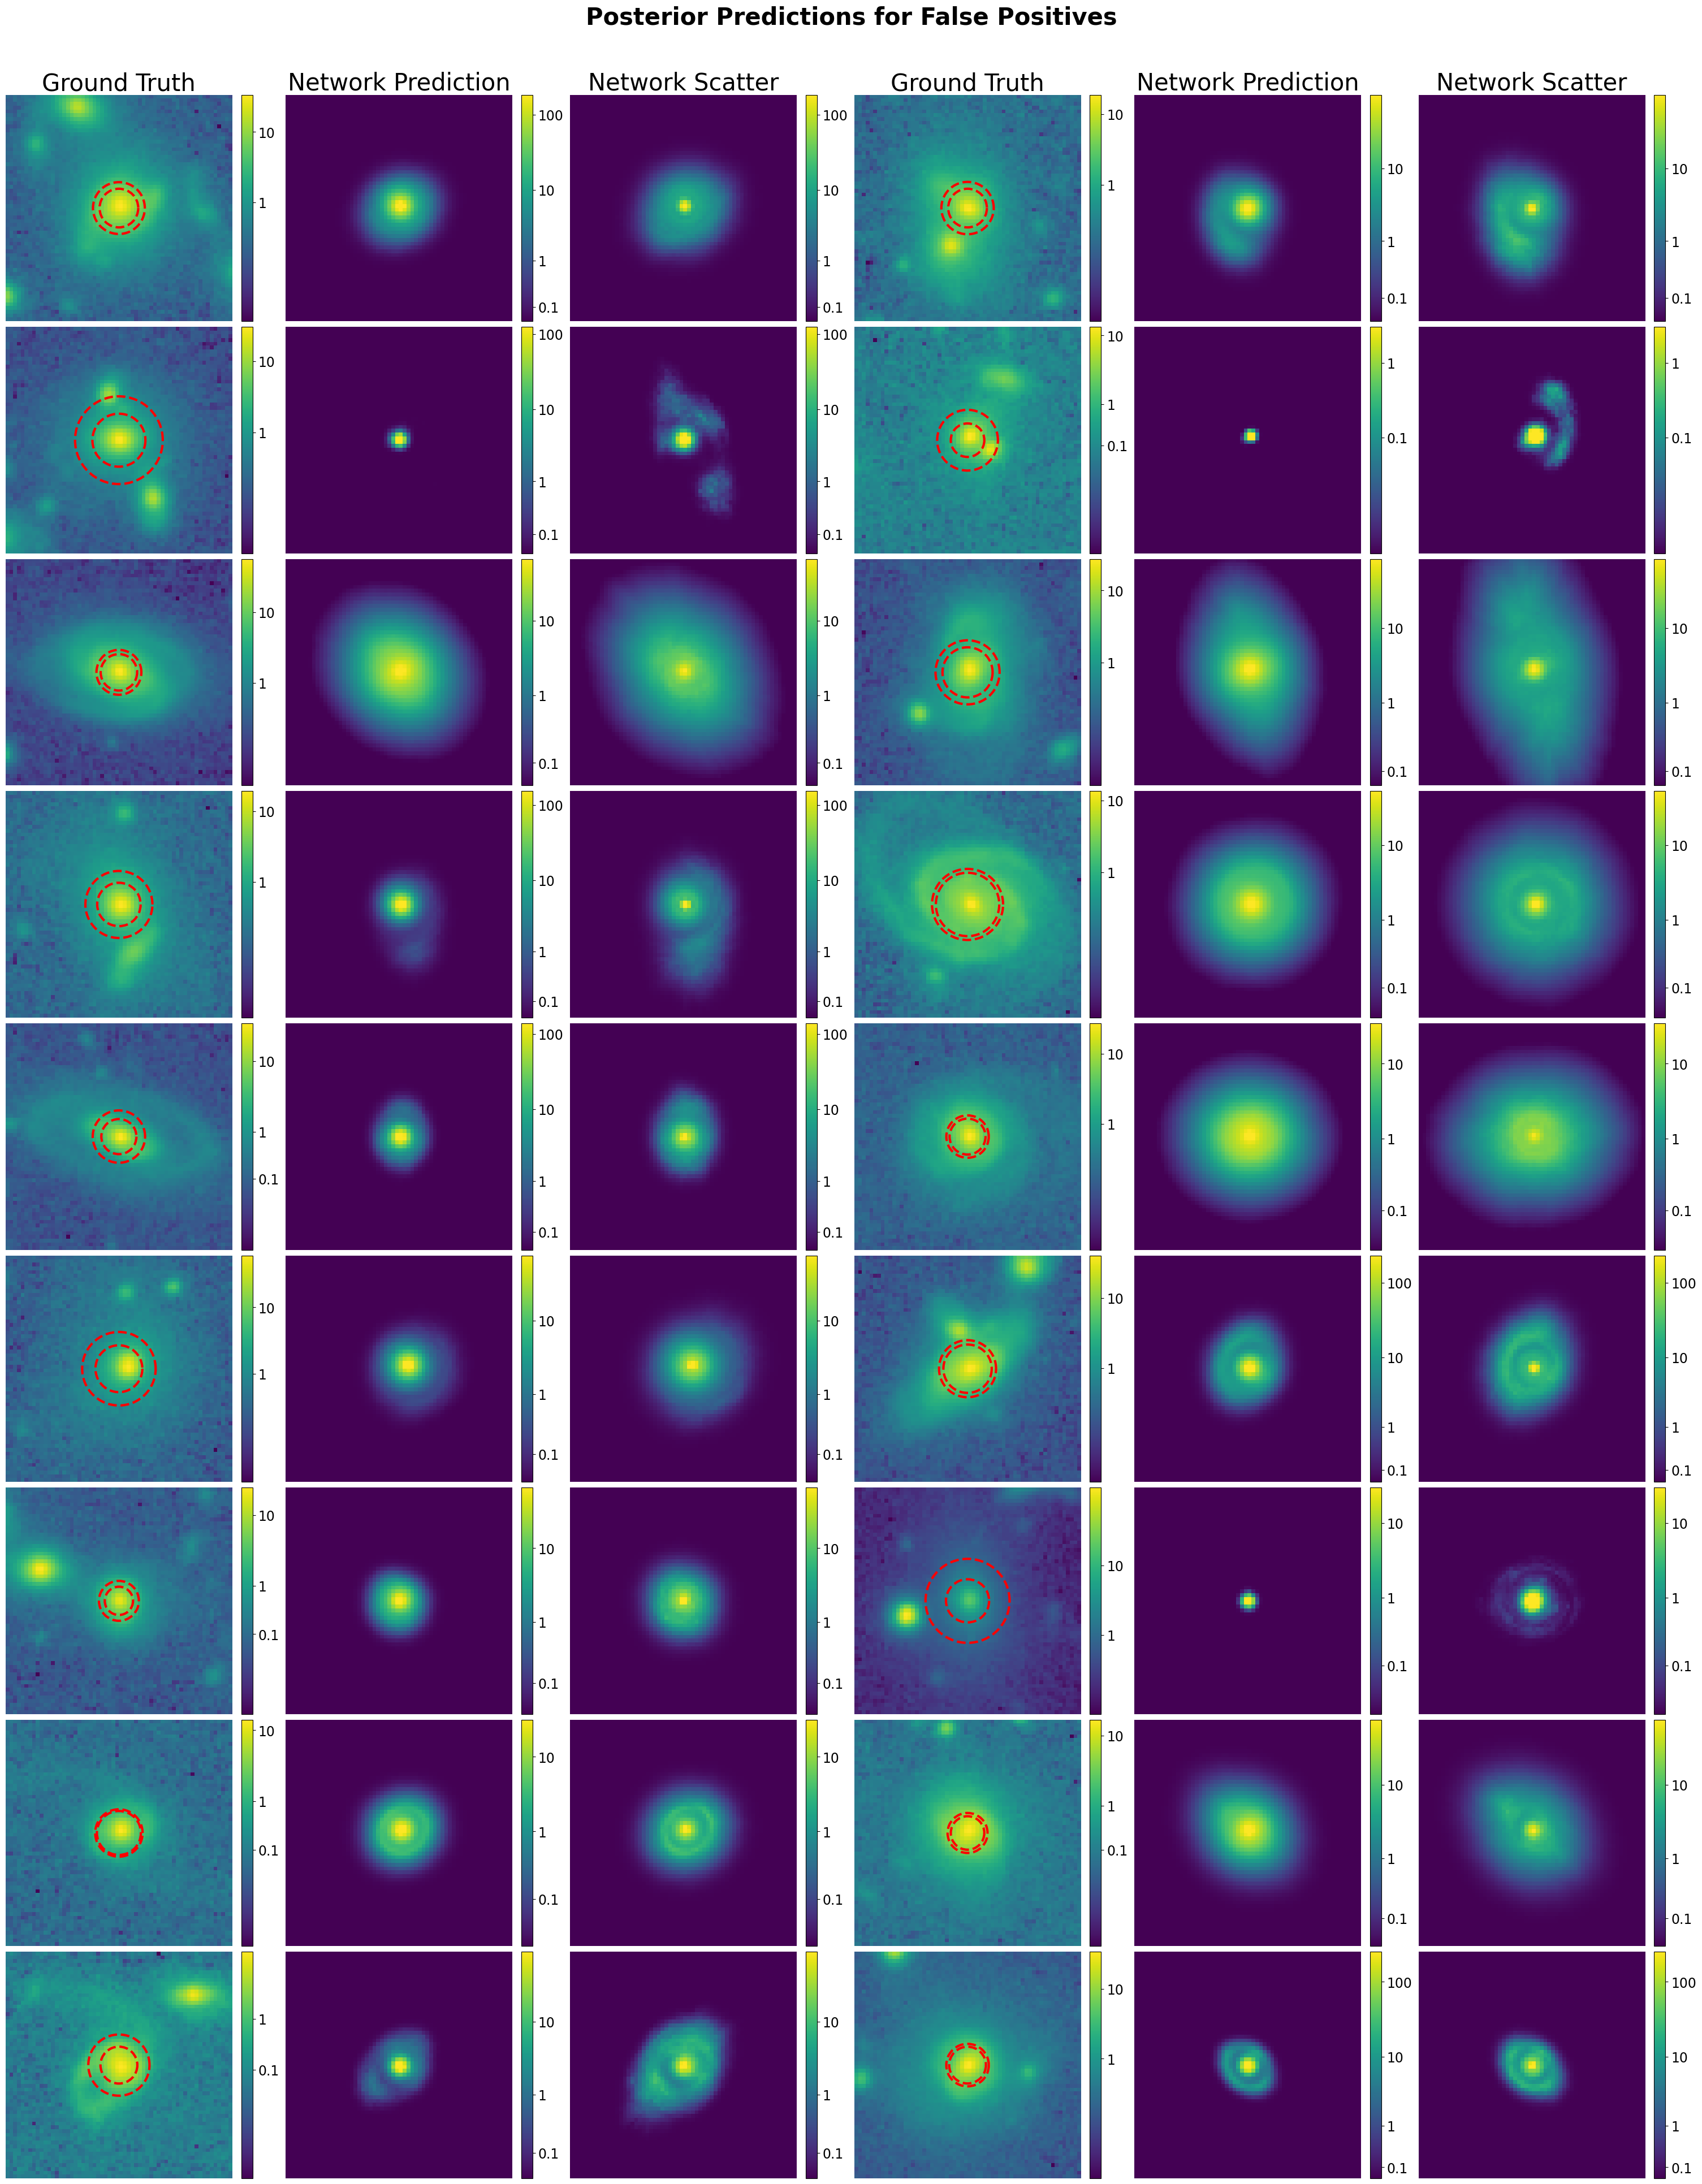

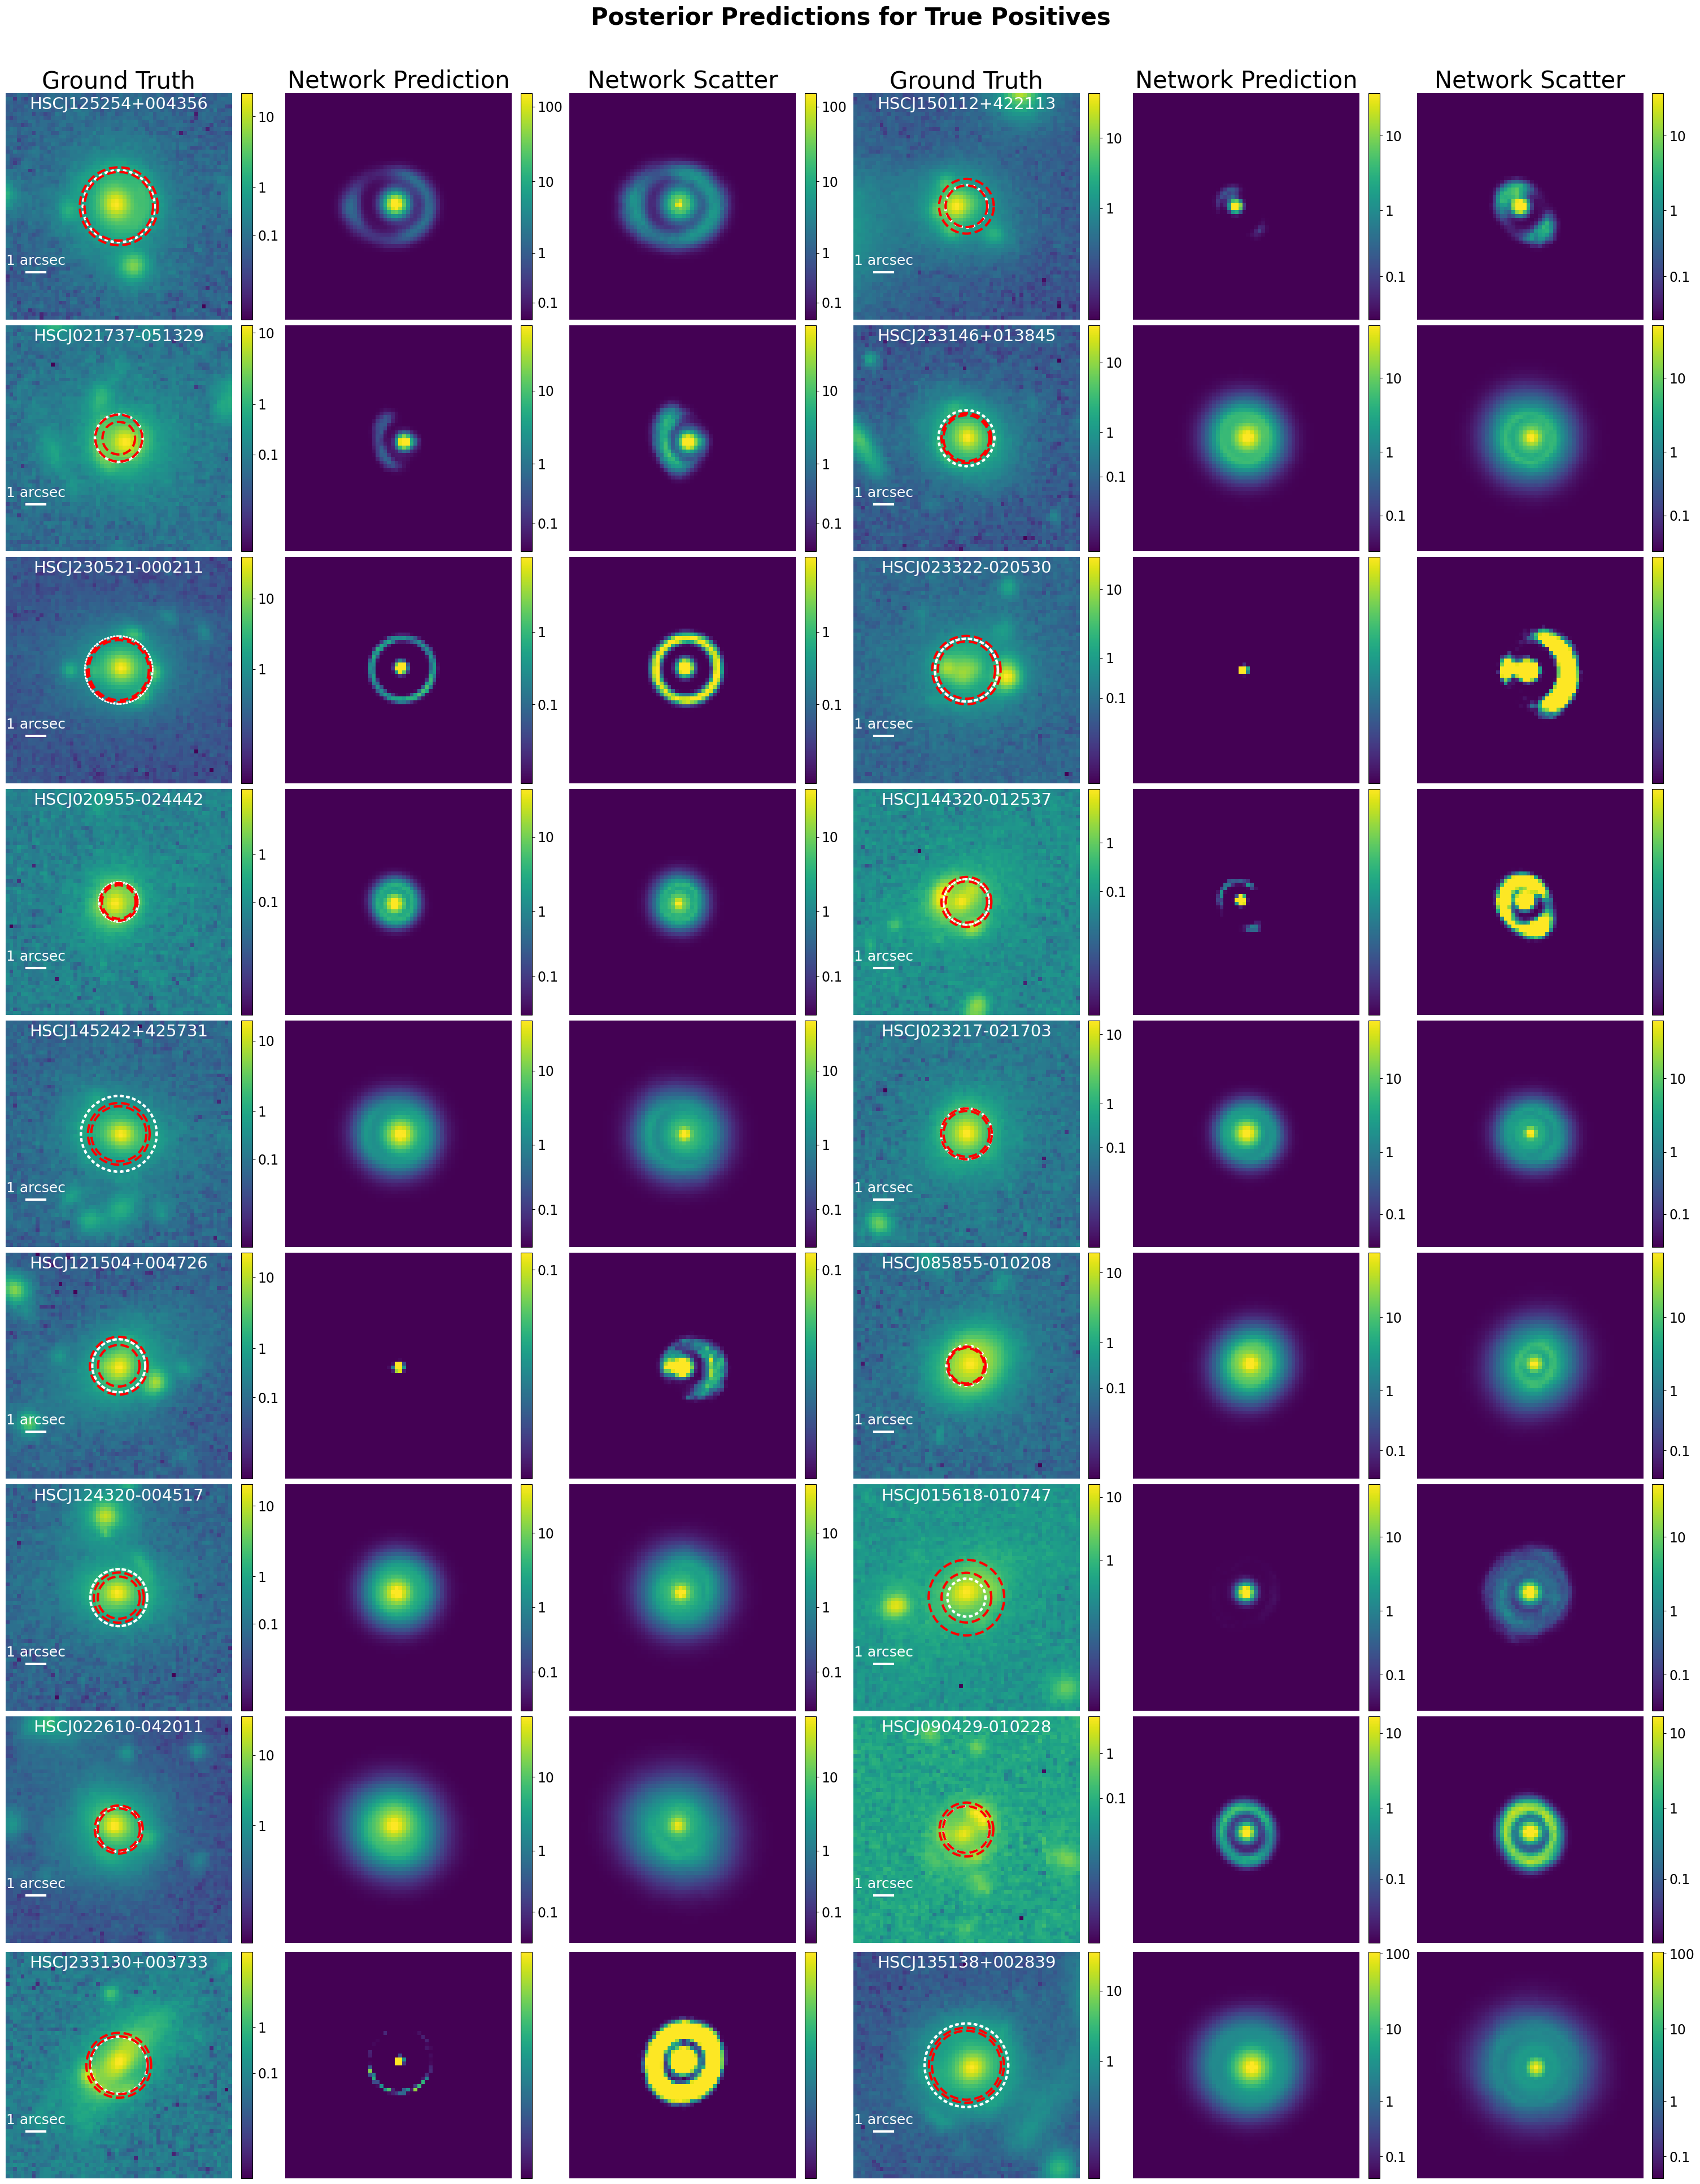

True Centre 0.0547874264593843
Predicted Centre 0.0545828677713871

True Centre -0.3691138889785787
Predicted Centre -0.3704373836517334

True Centre 0.2305031736222079
Predicted Centre 0.232336163520813

True Centre 0.1382488347241086
Predicted Centre 0.13689012825489044

True Centre -0.1035823257259264
Predicted Centre -0.10160521417856216

True Centre -0.1196228909087986
Predicted Centre -0.12060429155826569

True Centre -0.28415320027139
Predicted Centre -0.286135196685791

True Centre 0.2971259568100434
Predicted Centre 0.29821228981018066

True Centre 0.1057345882808842
Predicted Centre 0.10240638256072998

True Centre 0.4081314335328121
Predicted Centre 0.40757569670677185

True Centre 0.2584650133471401
Predicted Centre 0.27491647005081177

True Centre 0.0432947877385784
Predicted Centre 0.04119016230106354

True Centre 0.08776856926723
Predicted Centre 0.08699072152376175

True Centre 0.0597052396651632
Predicted Centre 0.06436721980571747

True Centre -0.0235377797303606
Pred

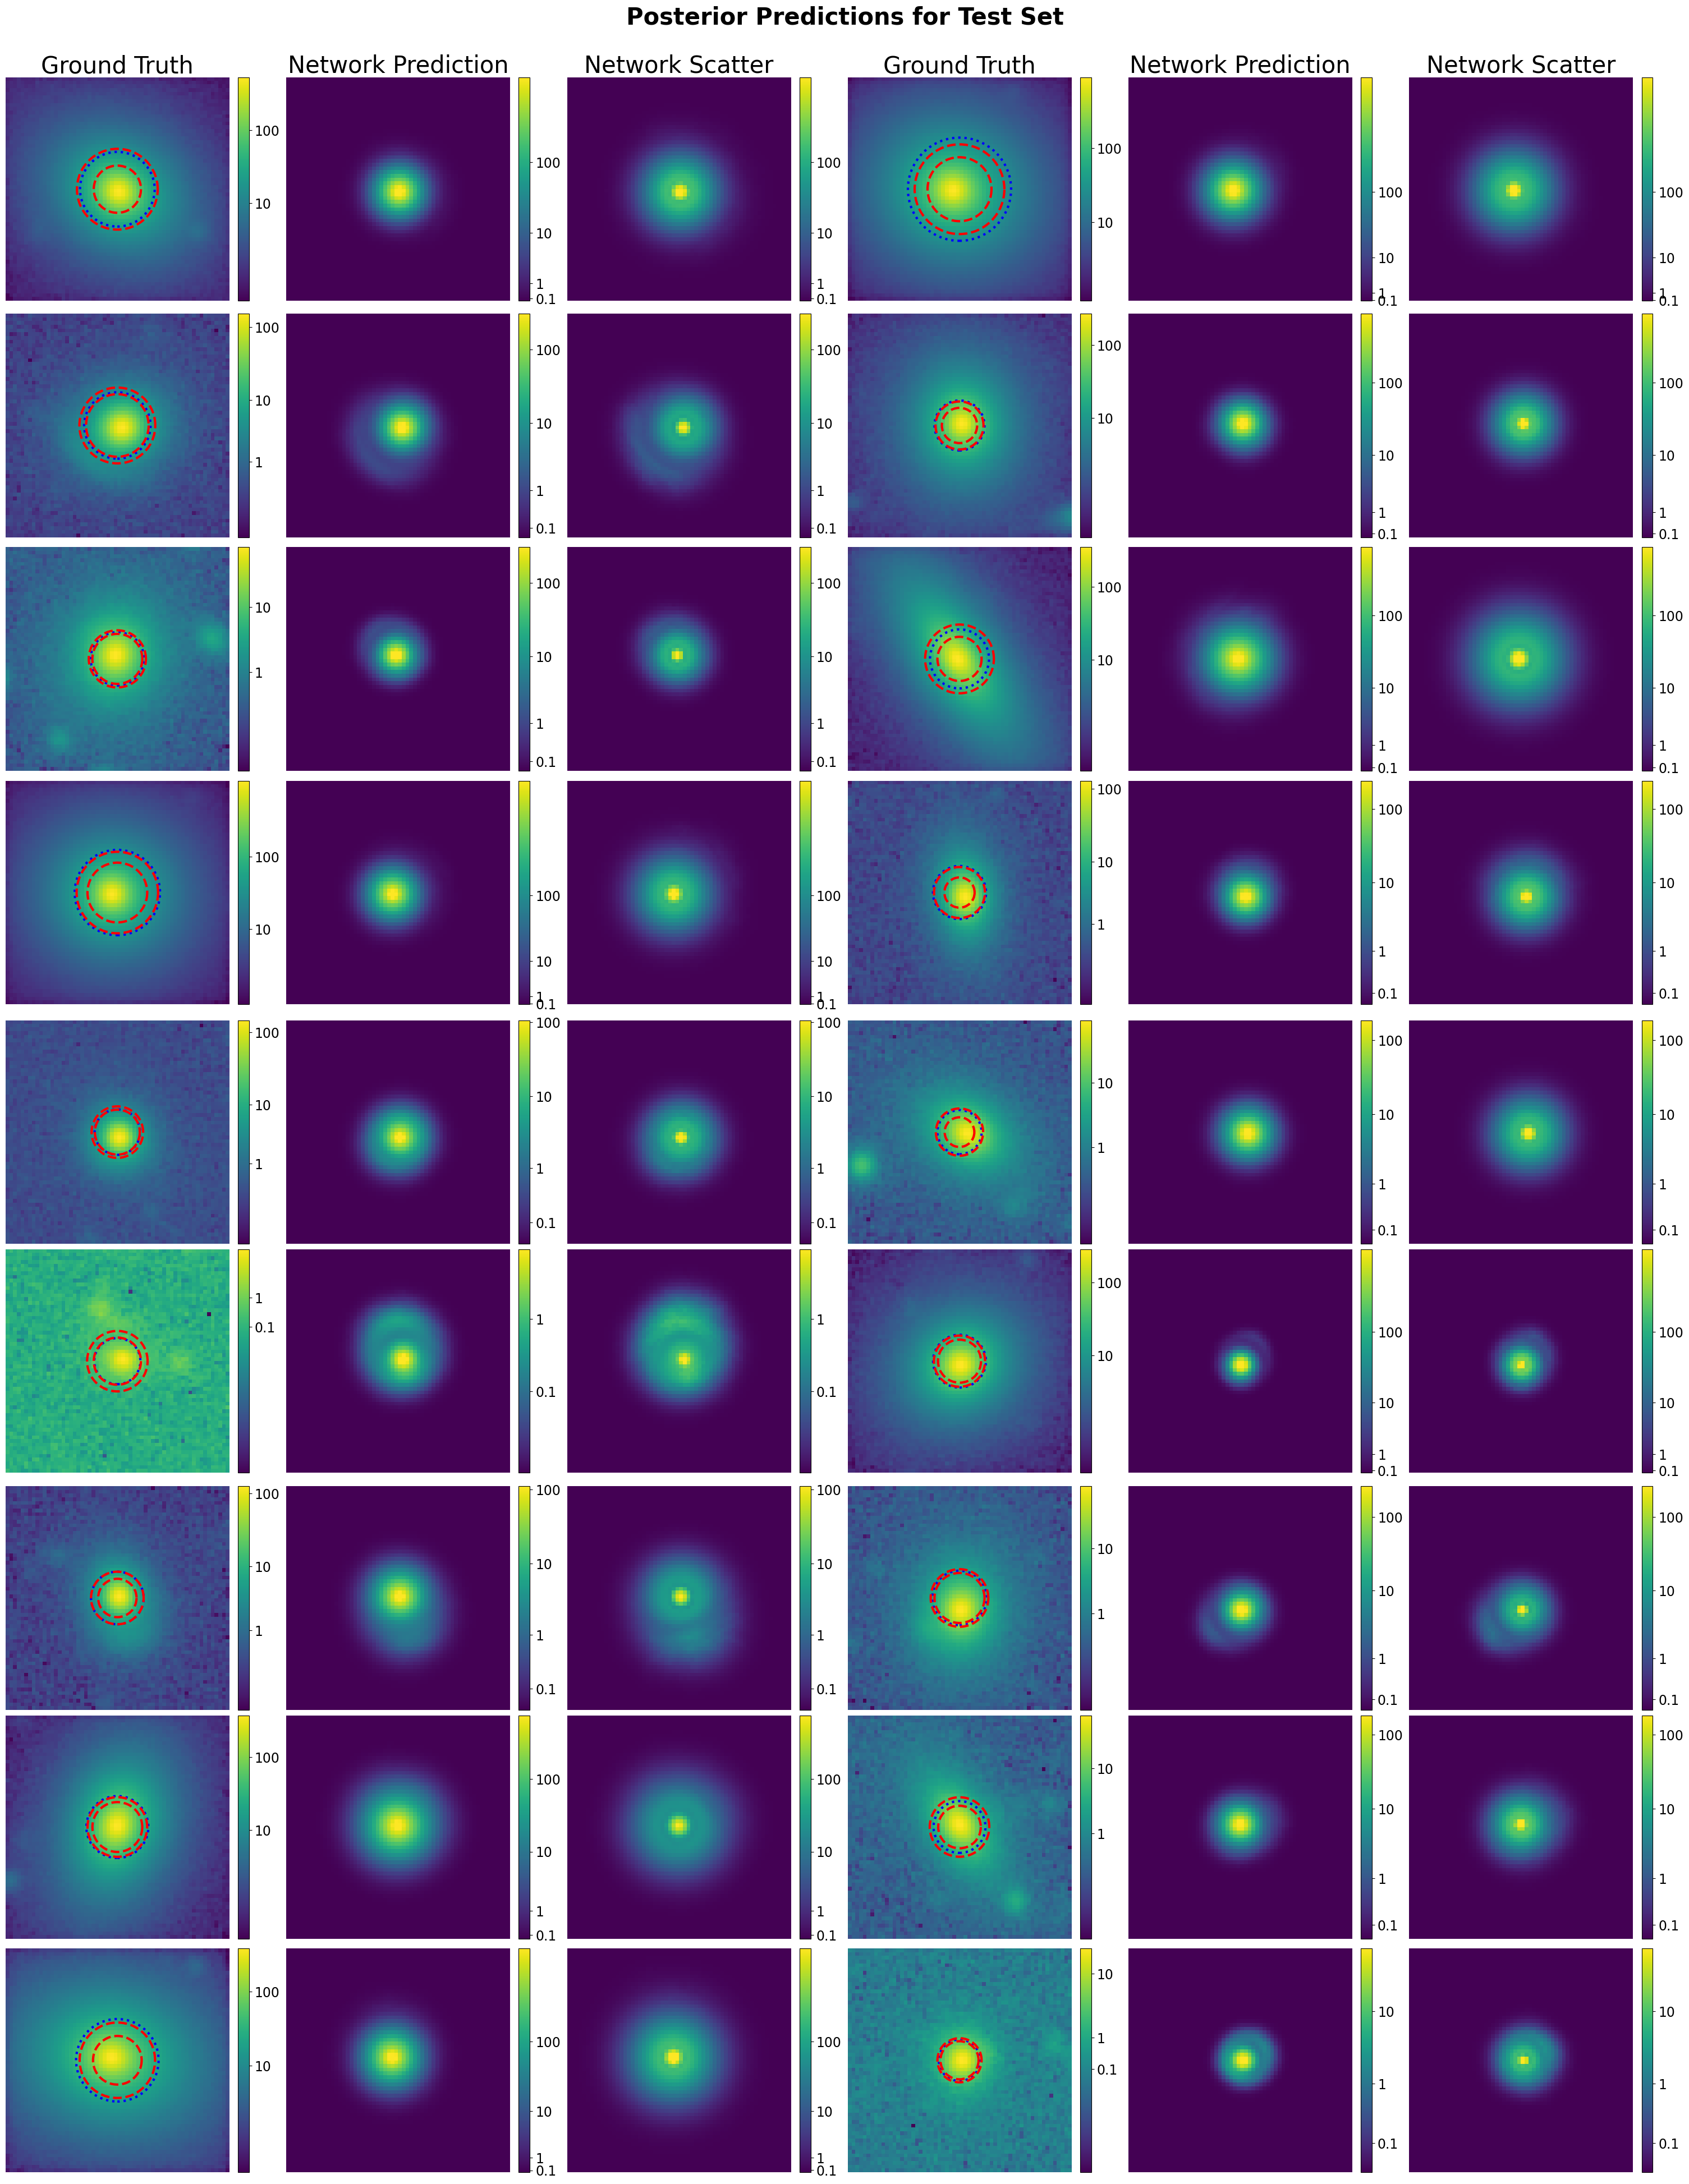

In [31]:
N_cols = 2
from matplotlib.patches import Annulus

fig,ax = pl.subplots(N_plot//N_cols,6,figsize=(30,5*N_plot//N_cols),layout='compressed')
ax = ax.reshape(-1,3)
posterior_image_class_FPs.plot_posterior_image(fig=fig,ax_all=ax,plot_image_name=False)
pl.suptitle('Posterior Predictions for False Positives',fontsize=30,fontweight='bold',y=0.94)
for fmt_i in ['.png','.pdf']:
    pl.savefig('/mnt/zfsusers/hollowayp/zBEAMS/zBEAMS_plots/Posterior_Predictions_FPs'+fmt_i,bbox_inches='tight')
pl.show()

fig,ax = pl.subplots(N_plot//N_cols,6,figsize=(30,5*N_plot//N_cols),layout='compressed')
ax = ax.reshape(-1,3)
posterior_image_class_TPs.plot_posterior_image(fig=fig,ax_all=ax,plot_image_name=True)
pl.suptitle('Posterior Predictions for True Positives',fontsize=30,fontweight='bold',y=0.94)
for fmt_i in ['.png','.pdf']:
    pl.savefig('/mnt/zfsusers/hollowayp/zBEAMS/zBEAMS_plots/Posterior_Predictions_TPs'+fmt_i,bbox_inches='tight')
pl.show()

# fig,ax = pl.subplots(N_plot//N_cols,8,figsize=(40,5*N_plot//N_cols),layout='compressed')
# ax = ax.reshape(-1,4)

fig,ax = pl.subplots(N_plot//N_cols,6,figsize=(30,5*N_plot//N_cols),layout='compressed')
ax = ax.reshape(-1,3)

posterior_image_class_testset.plot_posterior_image(fig=fig,ax_all=ax,plot_image_name=False,
                                                   test_data = True)
pl.suptitle('Posterior Predictions for Test Set',fontsize=30,fontweight='bold',y=0.94)
for fmt_i in ['.png','.pdf']:
    pl.savefig('/mnt/zfsusers/hollowayp/zBEAMS/zBEAMS_plots/Posterior_Predictions_TestSet'+fmt_i,bbox_inches='tight')
pl.show()

In [26]:
from load_h5_file import load_h5_file
Ex_40_test = load_h5_file('/mnt/extraspace/hollowayp/paltas_data/Example_LP_40_no_subtr/test/image_data.h5')
for image_n in tqdm(range(len(Ex_40_test))):
    im_i = Ex_40_test[image_n,:,:]
    np.save(f'/mnt/extraspace/hollowayp/paltas_data/Example_LP_40_no_subtr/test/test_as_npy_files/image_{str(image_n).zfill(7)}.npy',im_i)


100%|██████████| 24249/24249 [02:12<00:00, 183.38it/s]


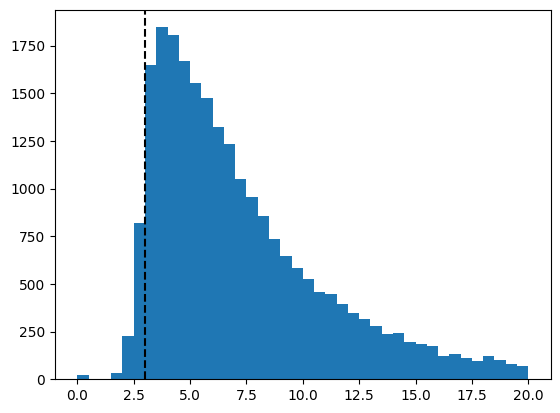

In [58]:
db_m = pd.read_csv('/mnt/extraspace/hollowayp/paltas_data/Example_LP_40_no_subtr/test/metadata.csv')
pl.hist(db_m.Magnification,bins=np.linspace(0,20,41))
pl.ylim(pl.ylim())
pl.plot([3,3],pl.ylim(),'k--')
pl.show()

In [ ]:
generate_config_module('/mnt/users/hollowayp/paltas/paltas/Configs/Examples/config_LSST_Lenspop_blank.py',
                                    {},{},{},
                                    detector_parameters = {'ccd_gain':0.7,
                                                        'read_noise':0,
                                                        'exposure_time':30,
                                                        'num_exposures':10000, #Making noiseless images at the moment.
                                                        'sky_brightness':100}, #Making noiseless images at the moment.
                                    PSF_parameters = {'fwhm':0.01},
                                    lens_subtraction=False)

In [ ]:
HS_X_db

In [ ]:
db_WandB = pd.read_csv('WandB Loss Evolution.csv')
for file_n in ['Example_LP_40']:
    for cov in ['','_fullcov']:
        for affix in ['',"_no_subtr","_no_RSP","_goodseeing",'_no_subtr_LS_light']:
            min_val_loss_step = np.where(db_WandB[f'{file_n}{affix}{cov} - Val Loss']==db_WandB[f'{file_n}{affix}{cov} - Val Loss'].min())[0][0]
            min_val_loss_epoch = min_val_loss_step+1
            print(file_n,cov,affix,
                  glob.glob(f'/mnt/extraspace/hollowayp/paltas_data/{file_n}{affix}{cov}/model_weights/{min_val_loss_epoch}-*.h5')[0])

In [ ]:
import glob
import numpy as np
import matplotlib.pyplot as pl
HSC_cutouts = glob.glob(f'/mnt/users/hollowayp/Documents/project_2/Ensemble_HSC_Cutout_Retrieval_{"99pct"}_FP_{"CS"}/cropped_cutouts/*.npy')
plot_collage(f'/mnt/users/hollowayp/Documents/project_2/Ensemble_HSC_Cutout_Retrieval_{"99pct"}_FP_{"CS"}/cropped_cutouts/',
             4,5,figsize=(20,16),tight_layout=True,vmax=20,vmin=0,interval='zscale',stretch='sqrt')


In [ ]:
db_000 = pd.read_csv('/mnt/extraspace/hollowayp/paltas_data/Example_LP_19/metadata_val.csv')
db_000.columns

In [ ]:
db_000[(db_000['main_deflector_parameters_theta_E']>1)
        #& (db_000['source_parameters_mag_app']<22)
        # & (abs(db_000['source_parameters_center_x'])<0.4)
        # & (abs(db_000['source_parameters_center_y'])<0.4)
        ].sort_values('Magnification',ascending=False)